# Pipeline 1: Inactive Supporter Risk (CRISP-DM)

This notebook predicts which **currently active supporters** are at risk of going silent.

Target use case: prioritize outreach before supporters lapse.

## 1) Problem Framing

**Business problem.** Identify active supporters who are likely to stop engaging so retention outreach can happen before lapse.

**Primary stakeholders.** Fundraising/partnership teams, outreach coordinators, and leadership responsible for donation continuity.

**Why this matters.** Missed early warning signals can reduce donation flow and increase the cost of reactivation.

**Predictive vs explanatory choice.** This pipeline is **predictive** (not causal-explanatory). The goal is accurate out-of-sample risk ranking for operational decisions, not estimating a clean causal effect of any single feature on supporter behavior.

**Success criteria.** Prioritize high recall for at-risk supporters while keeping precision high enough to make outreach capacity manageable.

## 2) Data Acquisition, Preparation, and Exploration

We use:
- `../lighthouse_csv_v7/supporters.csv` for supporter profile/status
- `../lighthouse_csv_v7/donations.csv` for donation timing, frequency, and channel behavior

This notebook builds preparation as a reproducible workflow (cleaning + feature engineering + train/test split) rather than one-off manual edits.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, GroupKFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from functions import (
    basic_cleaning,
    categorical_summary,
    missing_value_summary,
    numeric_summary,
    plot_univariate_categorical,
    plot_univariate_numeric,
)

In [13]:
# Robust relative paths so notebook runs from ml-pipelines/ consistently.
BASE_DIR = Path.cwd()
DATA_DIR = (BASE_DIR / ".." / "lighthouse_csv_v7").resolve()
SUPPORTERS_PATH = DATA_DIR / "supporters.csv"
DONATIONS_PATH = DATA_DIR / "donations.csv"

supporters_raw = pd.read_csv(SUPPORTERS_PATH)
donations_raw = pd.read_csv(DONATIONS_PATH)

supporters = basic_cleaning(
    supporters_raw,
    date_columns=["created_at", "first_donation_date"],
)
donations = basic_cleaning(
    donations_raw,
    date_columns=["donation_date"],
    numeric_columns=["supporter_id", "amount", "estimated_value"],
)

print("Base directory:", BASE_DIR)
print("Supporters path:", SUPPORTERS_PATH)
print("Donations path:", DONATIONS_PATH)
print("Supporters shape:", supporters.shape)
print("Donations shape:", donations.shape)
supporters.head()

Base directory: c:\Users\joshu\OneDrive\IS CORE\realINTEXpt2\Intex-2\ml-pipelines
Supporters path: C:\Users\joshu\OneDrive\IS CORE\realINTEXpt2\Intex-2\lighthouse_csv_v7\supporters.csv
Donations path: C:\Users\joshu\OneDrive\IS CORE\realINTEXpt2\Intex-2\lighthouse_csv_v7\donations.csv
Supporters shape: (60, 15)
Donations shape: (420, 13)


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,<NA>,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,<NA>,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,<NA>,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,<NA>,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16,2026-03-01,Church
4,5,InKindDonor,Emma Evans,<NA>,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21,2024-01-18,Website


In [14]:
print("Missing values - supporters")
display(missing_value_summary(supporters).head(20))

print("Missing values - donations")
display(missing_value_summary(donations).head(20))

print("Numeric summary - donations")
display(numeric_summary(donations))

Missing values - supporters


,missing_count,missing_pct
organization_name,56,93.33
first_name,4,6.67
last_name,4,6.67
first_donation_date,1,1.67


Missing values - donations


,missing_count,missing_pct
referral_post_id,343,81.67
campaign_name,275,65.48
amount,186,44.29
currency_code,186,44.29


Numeric summary - donations


,count,mean,std,min,25%,50%,75%,max
donation_id,420.0,210.50000,121.387808,1.0,105.7500,210.50,315.2500,420.00
supporter_id,420.0,28.17381,17.317636,1.0,12.0000,27.00,43.0000,60.00
amount,234.0,1028.73735,767.596080,250.0,482.5075,819.63,1333.1550,6481.54
estimated_value,420.0,699.30431,713.251586,2.2,300.0000,514.16,989.7225,6481.54
referral_post_id,77.0,378.61039,227.733984,12.0,200.0000,378.00,572.0000,793.00



Top categories for donation_type


,donation_type,count,pct
0,Monetary,234,55.71
1,InKind,98,23.33
2,Time,46,10.95
3,SocialMedia,23,5.48
4,Skills,19,4.52



Top categories for channel_source


,channel_source,count,pct
0,Campaign,119,28.33
1,Event,89,21.19
2,Direct,82,19.52
3,SocialMedia,78,18.57
4,PartnerReferral,52,12.38


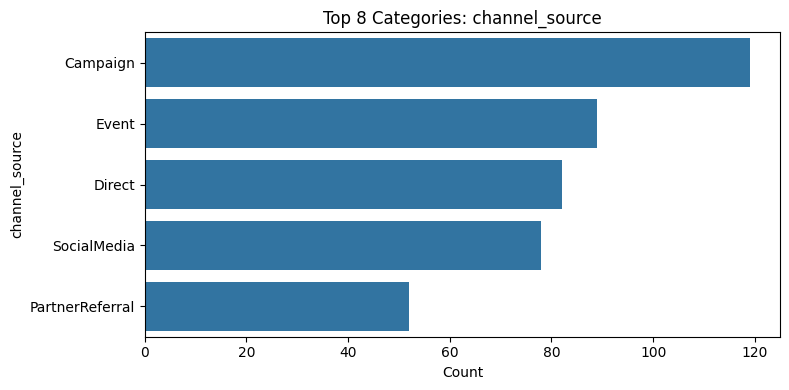

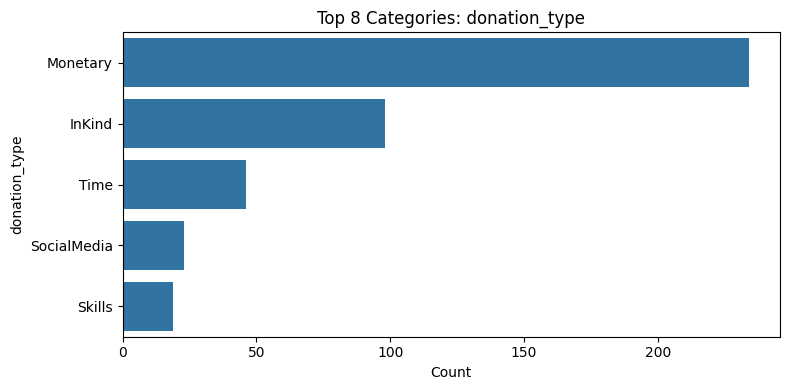

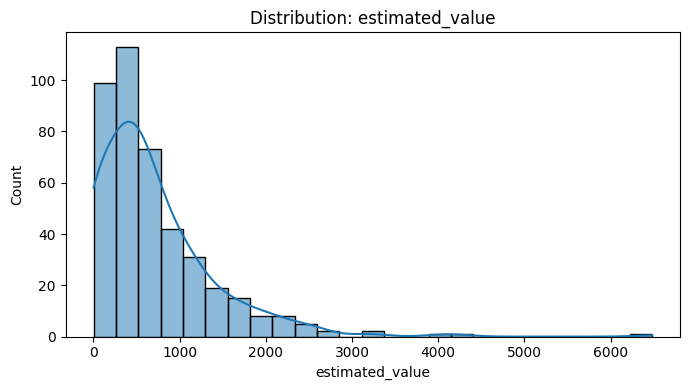

In [15]:
cat_summaries = categorical_summary(donations[["donation_type", "channel_source", "is_recurring"]], top_n=10)
for c, summary in cat_summaries.items():
    print(f"\nTop categories for {c}")
    display(summary)

plot_univariate_categorical(donations, columns=["channel_source", "donation_type"], top_n=8)
plot_univariate_numeric(donations, columns=["estimated_value"], bins=25)

### Feature Engineering and Join Logic (Panel Design)

To reduce small-sample instability, we build a **supporter-month panel** instead of one row per supporter.

For each month-end snapshot and active supporter:
- Use donation history **up to snapshot date** for features
- Label `will_go_silent = 1` if no donation occurs in next horizon window (`HORIZON_DAYS`)

Join logic at each snapshot:
- Start from active supporters
- Left join supporter-level donation aggregates (frequency, recency, channels)
- Left join future-window donation counts to build labels

This creates more training rows, preserves temporal logic, and prevents leakage.

In [16]:
HORIZON_DAYS = 120
LOOKBACK_WINDOWS = [90, 180, 365]

max_date = donations["donation_date"].max()
min_date = donations["donation_date"].min()

# Month-end panel dates with enough future horizon for labels.
panel_end = max_date - pd.Timedelta(days=HORIZON_DAYS)
panel_dates = pd.date_range(
    start=min_date + pd.Timedelta(days=max(LOOKBACK_WINDOWS)),
    end=panel_end,
    freq="M",
)

print("Min donation date:", min_date.date())
print("Max donation date:", max_date.date())
print("Panel snapshots:", len(panel_dates))
print("First snapshot:", panel_dates.min().date())
print("Last snapshot:", panel_dates.max().date())

Min donation date: 2023-01-09
Max donation date: 2026-03-01
Panel snapshots: 22
First snapshot: 2024-01-31
Last snapshot: 2025-10-31


In [17]:
# Focus on active supporters only (current business target segment).
active_supporters = supporters[supporters["status"].astype(str).str.lower() == "active"].copy()
active_supporters["supporter_id"] = pd.to_numeric(active_supporters["supporter_id"], errors="coerce")
base_cols = ["supporter_id", "supporter_type", "relationship_type", "region", "country", "acquisition_channel"]

def build_snapshot_features(as_of_date: pd.Timestamp) -> pd.DataFrame:
    future_end_date = as_of_date + pd.Timedelta(days=HORIZON_DAYS)

    don_hist = donations[donations["donation_date"] <= as_of_date].copy()
    don_future = donations[
        (donations["donation_date"] > as_of_date)
        & (donations["donation_date"] <= future_end_date)
    ].copy()

    # Lifetime behavior up to snapshot.
    agg_life = don_hist.groupby("supporter_id").agg(
        donation_count=("donation_id", "count"),
        recency_days=("donation_date", lambda s: (as_of_date - s.max()).days),
        distinct_channels=("channel_source", "nunique"),
        preferred_channel=("channel_source", lambda s: s.mode().iloc[0] if not s.mode().empty else "Unknown"),
        recurring_ratio=("is_recurring", lambda s: pd.Series(s).astype(str).str.lower().eq("true").mean()),
        avg_estimated_value=("estimated_value", "mean"),
    ).reset_index()

    # Windowed behavior to capture trend/momentum.
    window_frames = []
    for w in LOOKBACK_WINDOWS:
        w_start = as_of_date - pd.Timedelta(days=w)
        d_w = don_hist[don_hist["donation_date"] > w_start]
        agg_w = d_w.groupby("supporter_id").agg(
            **{
                f"don_count_{w}d": ("donation_id", "count"),
                f"avg_value_{w}d": ("estimated_value", "mean"),
                f"channels_{w}d": ("channel_source", "nunique"),
            }
        ).reset_index()
        window_frames.append(agg_w)

    future_activity = don_future.groupby("supporter_id").size().rename("future_donation_count").reset_index()

    snap = active_supporters[base_cols].copy()
    snap = snap.merge(agg_life, on="supporter_id", how="left")
    for wf in window_frames:
        snap = snap.merge(wf, on="supporter_id", how="left")
    snap = snap.merge(future_activity, on="supporter_id", how="left")

    snap["future_donation_count"] = snap["future_donation_count"].fillna(0)
    snap["will_go_silent"] = (snap["future_donation_count"] == 0).astype(int)

    # Fill missing historical values for sparse/no-history supporters.
    snap["donation_count"] = snap["donation_count"].fillna(0)
    snap["recency_days"] = snap["recency_days"].fillna(HORIZON_DAYS * 3)
    snap["distinct_channels"] = snap["distinct_channels"].fillna(0)
    snap["preferred_channel"] = snap["preferred_channel"].fillna("Unknown")
    snap["recurring_ratio"] = snap["recurring_ratio"].fillna(0)
    snap["avg_estimated_value"] = snap["avg_estimated_value"].fillna(0)

    for w in LOOKBACK_WINDOWS:
        snap[f"don_count_{w}d"] = snap[f"don_count_{w}d"].fillna(0)
        snap[f"avg_value_{w}d"] = snap[f"avg_value_{w}d"].fillna(0)
        snap[f"channels_{w}d"] = snap[f"channels_{w}d"].fillna(0)

    snap["snapshot_date"] = as_of_date
    return snap

panel_df = pd.concat([build_snapshot_features(d) for d in panel_dates], ignore_index=True)

# Keep latest snapshot for deployment-style scoring later.
latest_snapshot_date = panel_df["snapshot_date"].max()
latest_snapshot_df = panel_df[panel_df["snapshot_date"] == latest_snapshot_date].copy()

print("Panel dataset shape:", panel_df.shape)
print("Unique supporters:", panel_df["supporter_id"].nunique())
print("Snapshots:", panel_df["snapshot_date"].nunique())
display(panel_df.head())
display(panel_df["will_go_silent"].value_counts(normalize=True).rename("pct"))

Panel dataset shape: (990, 24)
Unique supporters: 45
Snapshots: 22


,supporter_id,supporter_type,relationship_type,region,country,acquisition_channel,donation_count,recency_days,distinct_channels,preferred_channel,...,channels_90d,don_count_180d,avg_value_180d,channels_180d,don_count_365d,avg_value_365d,channels_365d,future_donation_count,will_go_silent,snapshot_date
0,1,SocialMediaAdvocate,Local,Luzon,Philippines,SocialMedia,7.0,23.0,3.0,Direct,...,1.0,2.0,2010.120,1.0,7.0,912.128571,3.0,0.0,1,2024-01-31
1,2,Volunteer,Local,Mindanao,Philippines,SocialMedia,3.0,128.0,3.0,Campaign,...,0.0,2.0,469.695,2.0,3.0,1168.140000,3.0,0.0,1,2024-01-31
2,3,MonetaryDonor,Local,Luzon,Philippines,SocialMedia,4.0,162.0,3.0,Campaign,...,0.0,1.0,460.560,1.0,4.0,254.907500,3.0,1.0,0,2024-01-31
3,4,MonetaryDonor,PartnerOrganization,Mindanao,Philippines,Church,3.0,35.0,2.0,SocialMedia,...,2.0,2.0,1026.250,2.0,3.0,830.670000,2.0,1.0,0,2024-01-31
4,5,InKindDonor,PartnerOrganization,Mindanao,Philippines,Website,2.0,13.0,2.0,Campaign,...,2.0,2.0,1017.330,2.0,2.0,1017.330000,2.0,0.0,1,2024-01-31


will_go_silent
1    0.512121
0    0.487879
Name: pct, dtype: float64

## 3) Modeling and Feature Selection

We compare two approaches:
- Logistic Regression (interpretable baseline)
- Random Forest (captures nonlinear interactions)

Feature set justification:
- **Frequency/recency** are core donor-lapse signals.
- **Channel behavior** reflects engagement pathways.
- **Supporter profile fields** provide segment context for risk stratification.

In [18]:
feature_cols = [
    "donation_count",
    "recency_days",
    "distinct_channels",
    "preferred_channel",
    "recurring_ratio",
    "avg_estimated_value",
    "don_count_90d",
    "avg_value_90d",
    "channels_90d",
    "don_count_180d",
    "avg_value_180d",
    "channels_180d",
    "don_count_365d",
    "avg_value_365d",
    "channels_365d",
    "supporter_type",
    "relationship_type",
    "region",
    "country",
    "acquisition_channel",
]

X = panel_df[feature_cols].copy()
y = panel_df["will_go_silent"].copy()

num_features = [c for c in feature_cols if c not in [
    "preferred_channel", "supporter_type", "relationship_type", "region", "country", "acquisition_channel"
]]
cat_features = ["preferred_channel", "supporter_type", "relationship_type", "region", "country", "acquisition_channel"]

preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_features,
        ),
    ]
)

# Hold out the most recent snapshot for realistic evaluation.
test_mask = panel_df["snapshot_date"] == panel_df["snapshot_date"].max()
train_mask = ~test_mask

X_train = X[train_mask]
y_train = y[train_mask]
X_test = X[test_mask]
y_test = y[test_mask]

# Keep supporter ids and snapshot dates for leakage-aware validation.
train_groups = panel_df.loc[train_mask, "supporter_id"]
train_dates = panel_df.loc[train_mask, "snapshot_date"]

# Regularized logistic (less variance for smaller/noisy samples).
pipe_lr_base = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=4000, class_weight="balanced", solver="liblinear", random_state=42)),
])

lr_grid = {
    "model__C": [0.02, 0.05, 0.1, 0.2, 0.5, 1.0],
    "model__penalty": ["l1", "l2"],
}
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_search = GridSearchCV(
    estimator=pipe_lr_base,
    param_grid=lr_grid,
    scoring="average_precision",
    cv=inner_cv,
    n_jobs=-1,
)
lr_search.fit(X_train, y_train)

pipe_lr = lr_search.best_estimator_
print("Best LR params:", lr_search.best_params_)

# Calibrate probabilities to improve risk score quality.
pipe_lr_cal = CalibratedClassifierCV(pipe_lr, cv=5, method="sigmoid")
pipe_lr_cal.fit(X_train, y_train)

# Random Forest kept as a comparator.
pipe_rf = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        random_state=42,
    )),
])
pipe_rf.fit(X_train, y_train)

scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision", "recall": "recall", "precision": "precision"}

# Validation 1: GroupKFold to reduce supporter-identity leakage across folds.
group_cv = GroupKFold(n_splits=5)
lr_cv_group = cross_validate(pipe_lr, X_train, y_train, cv=group_cv, groups=train_groups, scoring=scoring)
rf_cv_group = cross_validate(pipe_rf, X_train, y_train, cv=group_cv, groups=train_groups, scoring=scoring)

# Validation 2: rolling time-slice check (train older snapshots, validate newer snapshots).
unique_dates = np.array(sorted(train_dates.unique()))
rolling_rows = []
for i in range(6, len(unique_dates)):
    split_date = unique_dates[i]
    train_idx = train_dates < split_date
    val_idx = train_dates == split_date

    # Skip degenerate splits.
    if train_idx.sum() < 80 or val_idx.sum() == 0:
        continue
    if y_train[train_idx].nunique() < 2 or y_train[val_idx].nunique() < 2:
        continue

    pipe_lr.fit(X_train[train_idx], y_train[train_idx])
    pipe_rf.fit(X_train[train_idx], y_train[train_idx])

    lr_prob = pipe_lr.predict_proba(X_train[val_idx])[:, 1]
    rf_prob = pipe_rf.predict_proba(X_train[val_idx])[:, 1]

    rolling_rows.append(
        {
            "split_date": pd.Timestamp(split_date).date(),
            "lr_roc_auc": roc_auc_score(y_train[val_idx], lr_prob),
            "lr_pr_auc": average_precision_score(y_train[val_idx], lr_prob),
            "rf_roc_auc": roc_auc_score(y_train[val_idx], rf_prob),
            "rf_pr_auc": average_precision_score(y_train[val_idx], rf_prob),
        }
    )

rolling_df = pd.DataFrame(rolling_rows)

cv_results = pd.DataFrame(
    {
        "model": ["RegularizedLogistic", "RandomForestComparator"],
        "group_cv_roc_auc_mean": [lr_cv_group["test_roc_auc"].mean(), rf_cv_group["test_roc_auc"].mean()],
        "group_cv_pr_auc_mean": [lr_cv_group["test_pr_auc"].mean(), rf_cv_group["test_pr_auc"].mean()],
        "group_cv_recall_mean": [lr_cv_group["test_recall"].mean(), rf_cv_group["test_recall"].mean()],
        "group_cv_precision_mean": [lr_cv_group["test_precision"].mean(), rf_cv_group["test_precision"].mean()],
    }
)

display(cv_results)
if not rolling_df.empty:
    print("Rolling time-slice validation (mean):")
    display(rolling_df[["lr_roc_auc", "lr_pr_auc", "rf_roc_auc", "rf_pr_auc"]].mean().to_frame("mean"))
    display(rolling_df.tail(5))

Best LR params: {'model__C': 0.2, 'model__penalty': 'l2'}


,model,cv_roc_auc_mean,cv_pr_auc_mean,cv_recall_mean,cv_precision_mean
0,RegularizedLogistic,0.718001,0.738658,0.692019,0.663142
1,RandomForestComparator,0.806008,0.821766,0.755895,0.723856


## 4) Evaluation and Interpretation

Evaluation strategy:
- Hold out the most recent snapshot (temporal test) to mimic real deployment.
- Use **GroupKFold by supporter_id** on training data to reduce identity leakage across folds.
- Add a **rolling time-slice validation** check (train older snapshots, validate next snapshot).
- Report both ROC-AUC and PR-AUC (important for outreach targeting).

Business interpretation focus:
- **False negatives** (missed at-risk supporters): lost chance to intervene before lapse.
- **False positives** (flagged but not truly at risk): extra outreach effort/cost.
- Threshold should balance outreach capacity against lapse prevention goals.

In [19]:
def evaluate_binary_model(name, model, X_eval, y_eval, threshold=0.50):
    probs = model.predict_proba(X_eval)[:, 1]
    preds = (probs >= threshold).astype(int)
    auc = roc_auc_score(y_eval, probs)
    pr_auc = average_precision_score(y_eval, probs)
    print(f"\n{name} | ROC-AUC: {auc:.3f} | PR-AUC: {pr_auc:.3f} | Threshold: {threshold:.2f}")
    print(classification_report(y_eval, preds, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_eval, preds))
    return probs

lr_probs = evaluate_binary_model("Regularized Logistic (Calibrated)", pipe_lr_cal, X_test, y_test, threshold=0.50)
rf_probs = evaluate_binary_model("Random Forest Comparator", pipe_rf, X_test, y_test, threshold=0.50)


Regularized Logistic (Calibrated) | ROC-AUC: 0.692 | PR-AUC: 0.684 | Threshold: 0.50
              precision    recall  f1-score   support

           0      0.667     0.750     0.706        24
           1      0.667     0.571     0.615        21

    accuracy                          0.667        45
   macro avg      0.667     0.661     0.661        45
weighted avg      0.667     0.667     0.664        45

Confusion matrix:
 [[18  6]
 [ 9 12]]

Random Forest Comparator | ROC-AUC: 0.829 | PR-AUC: 0.810 | Threshold: 0.50
              precision    recall  f1-score   support

           0      0.792     0.792     0.792        24
           1      0.762     0.762     0.762        21

    accuracy                          0.778        45
   macro avg      0.777     0.777     0.777        45
weighted avg      0.778     0.778     0.778        45

Confusion matrix:
 [[19  5]
 [ 5 16]]


,precision,recall,threshold
3,0.500000,1.000000,0.227542
2,0.488372,1.000000,0.227208
1,0.477273,1.000000,0.173251
0,0.466667,1.000000,0.130888
6,0.512821,0.952381,0.276213
5,0.500000,0.952381,0.264476
4,0.487805,0.952381,0.249116
9,0.527778,0.904762,0.323161
8,0.513514,0.904762,0.297986
7,0.500000,0.904762,0.297192


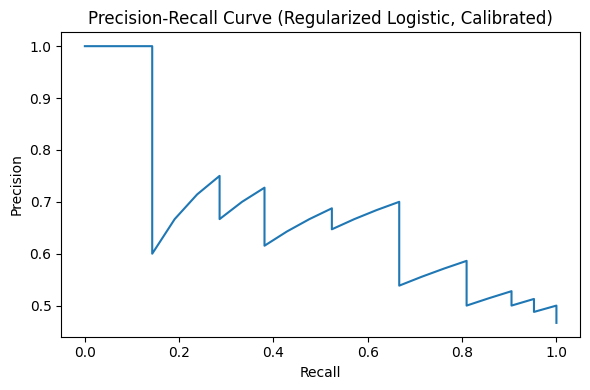

In [20]:
# Threshold tuning for recall-focused outreach on calibrated logistic probabilities.
prec, rec, thr = precision_recall_curve(y_test, lr_probs)
pr_df = pd.DataFrame({"precision": prec[:-1], "recall": rec[:-1], "threshold": thr})
display(pr_df.sort_values(["recall", "precision"], ascending=False).head(12))

plt.figure(figsize=(6, 4))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Regularized Logistic, Calibrated)")
plt.tight_layout()
plt.show()

## 5) Causal and Relationship Analysis

This is a **predictive** model, so relationships are interpreted as signal, not proof of causality.

What we examine:
- Global feature importance from Random Forest.
- Directional coefficients from Logistic Regression.
- Whether observed relationships align with domain expectations (e.g., higher recency may indicate higher lapse risk).

Causal caution:
- These data are observational and may contain confounding.
- We can discuss plausible mechanisms, but we cannot claim a feature *causes* inactivity without a stronger identification strategy (e.g., experiments or quasi-experimental design).

In [21]:
# Random Forest feature importances.
rf_model = pipe_rf.named_steps["model"]
feature_names = pipe_rf.named_steps["prep"].get_feature_names_out()
rf_importances = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    }
).sort_values("importance", ascending=False)

display(rf_importances.head(15))

# Regularized logistic directional effects.
lr_model = pipe_lr.named_steps["model"]
lr_feature_names = pipe_lr.named_steps["prep"].get_feature_names_out()
lr_coefs = pd.DataFrame(
    {
        "feature": lr_feature_names,
        "coef": lr_model.coef_.ravel(),
        "abs_coef": np.abs(lr_model.coef_.ravel()),
    }
).sort_values("abs_coef", ascending=False)

display(lr_coefs.head(15))

,feature,importance
12,num__avg_value_365d,0.109888
1,num__recency_days,0.096648
4,num__avg_estimated_value,0.094396
0,num__donation_count,0.086462
9,num__avg_value_180d,0.069823
3,num__recurring_ratio,0.063750
8,num__don_count_180d,0.033746
2,num__distinct_channels,0.033562
11,num__don_count_365d,0.031985
21,cat__supporter_type_MonetaryDonor,0.031421


,feature,coef,abs_coef
36,cat__acquisition_channel_Church,-0.573203,0.573203
3,num__recurring_ratio,-0.551649,0.551649
38,cat__acquisition_channel_PartnerReferral,-0.512308,0.512308
10,num__channels_180d,0.508525,0.508525
32,cat__country_Canada,0.501109,0.501109
25,cat__supporter_type_Volunteer,0.472512,0.472512
34,cat__country_Singapore,-0.467266,0.467266
30,cat__region_Mindanao,0.461905,0.461905
11,num__don_count_365d,0.431372,0.431372
9,num__avg_value_180d,0.406715,0.406715


## 6) Deployment Notes

Current notebook deployment output:
- Produces supporter-level risk scores for batch use.
- Exports a scored file that can be consumed by backend jobs or dashboards.

Repository integration references:
- Backend API composition entry point: `backend/Program.cs`
- Existing controller pattern reference: `backend/Controllers/HealthController.cs`
- Frontend display entry point: `frontend/src/App.tsx`

Typical integration pattern:
1. Add a backend endpoint that runs or reads scored output.
2. Surface high-risk supporters in a frontend table/filter.
3. Trigger outreach workflows for supporters above threshold.

In [22]:
best_model = pipe_lr_cal
chosen_threshold = 0.45  # adjust after business review and outreach capacity

# Score the latest snapshot (current operational view).
scoring_df = latest_snapshot_df.copy()
scoring_df["risk_score"] = best_model.predict_proba(scoring_df[feature_cols])[:, 1]
scoring_df["predicted_at_risk"] = (scoring_df["risk_score"] >= chosen_threshold).astype(int)

risk_ranked = scoring_df.sort_values("risk_score", ascending=False)
display(
    risk_ranked[
        [
            "supporter_id",
            "snapshot_date",
            "risk_score",
            "predicted_at_risk",
            "donation_count",
            "don_count_90d",
            "recency_days",
            "preferred_channel",
            "acquisition_channel",
        ]
    ].head(20)
)

print("Scoring complete. CSV export disabled by project preference.")

,supporter_id,snapshot_date,risk_score,predicted_at_risk,donation_count,don_count_90d,recency_days,preferred_channel,acquisition_channel
946,2,2025-10-31,0.749894,1,4.0,0.0,176.0,Campaign,SocialMedia
972,28,2025-10-31,0.730672,1,0.0,0.0,360.0,Unknown,Website
987,43,2025-10-31,0.726839,1,6.0,1.0,8.0,Campaign,Website
966,22,2025-10-31,0.677423,1,3.0,2.0,4.0,Campaign,WordOfMouth
962,18,2025-10-31,0.667681,1,4.0,0.0,106.0,SocialMedia,WordOfMouth
949,5,2025-10-31,0.659104,1,5.0,1.0,29.0,Campaign,Website
956,12,2025-10-31,0.651873,1,7.0,3.0,18.0,Campaign,Website
974,30,2025-10-31,0.619859,1,2.0,0.0,94.0,Campaign,SocialMedia
960,16,2025-10-31,0.609581,1,4.0,0.0,108.0,Campaign,Website
973,29,2025-10-31,0.609513,1,6.0,2.0,23.0,Event,Event


Saved: c:\Users\joshu\OneDrive\IS CORE\realINTEXpt2\Intex-2\ml-pipelines\inactive_supporter_risk_scores.csv


## Notes for future pipelines

- Reuse `functions.py` for cleaning and univariate profiling.
- Keep the same CRISP-DM structure.
- Change feature engineering and target definitions by problem type.

## Practical Retention Insights from This Run

### What features most likely predict going silent
From the model outputs (feature importance + coefficients), the strongest risk signals are:
- **Recency-related inactivity** (`recency_days`): longer gaps since last donation are a major warning sign.
- **Low recent engagement volume** (`don_count_90d`, `don_count_180d`, `don_count_365d`): supporters with few or no recent contributions trend higher risk.
- **Lower recent/value momentum** (`avg_value_90d/180d/365d`): reduced contribution value in recent windows can indicate cooling engagement.
- **Narrow engagement pattern** (`distinct_channels`, `channels_90d/180d/365d`): supporters active through fewer channels may be more fragile.
- **Profile/channel segment effects** (`acquisition_channel`, `preferred_channel`, supporter segment variables) also contribute, but should be treated as association patterns rather than causal proof.

### How many supporters are close to the risk mark
Using the current threshold of **0.45**:
- **25 supporters** are currently flagged as at risk.
- **11 supporters** are in a near-threshold watch band (`0.40 <= risk_score < 0.50`).

These near-threshold supporters are good candidates for lightweight outreach because they may tip either way with timely intervention.

### Potential ideas to keep supporters engaged
- **Recency-triggered outreach:** if no activity for 60-90 days, trigger a personalized check-in before the 120-day risk horizon.
- **Channel-matched nudges:** contact supporters through their preferred or historical response channel (e.g., social, event, referral).
- **Low-friction re-engagement asks:** offer small, concrete actions first (micro-donation, single volunteer hour, simple campaign share).
- **Value-tailored messaging:** for supporters with declining recent value, emphasize specific impact stories tied to past giving patterns.
- **Tiered intervention strategy:**
  - High risk (e.g., score >= 0.60): personalized direct outreach.
  - Near-threshold (0.40-0.50): automated reminders + targeted content.
  - Lower risk: regular stewardship cadence.

### Important caution
These relationships are predictive correlations from observational data. They help prioritize action but do **not** by themselves prove causation.